In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.float_format', '{:.4f}'.format)

DATA_DIR = "../data"

In [3]:
df = pd.read_csv(DATA_DIR+"/water_leak_detection_1000_rows.csv")
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
print(df.shape)
df.head(10)


(1000, 7)


,Timestamp,Sensor_ID,Pressure (bar),Flow Rate (L/s),Temperature (°C),Leak Status,Burst Status
0,2024-01-01 00:00:00,S007,3.6948,77.5152,21.6954,0,0
1,2024-01-01 00:05:00,S007,2.5871,179.9264,19.0167,0,0
2,2024-01-01 00:10:00,S002,2.4490,210.1308,10.0117,1,0
3,2024-01-01 00:15:00,S009,2.9368,141.7779,12.0924,0,0
4,2024-01-01 00:20:00,S003,3.0737,197.4846,17.0014,0,0
5,2024-01-01 00:25:00,S009,2.5976,192.3328,24.4845,0,0
6,2024-01-01 00:30:00,S005,2.8463,86.1538,20.2490,0,0
7,2024-01-01 00:35:00,S003,3.8640,88.8170,19.9378,0,0
8,2024-01-01 00:40:00,S010,3.3516,54.6970,22.6343,0,0
9,2024-01-01 00:45:00,S004,3.3968,188.2811,11.3274,0,0


In [4]:
print("=== DTYPES ===")
print(df.dtypes)
print("\n=== NULL VALUES ===")
print(df.isnull().sum())
print("\n=== DATE RANGE ===")
print("From :", df['Timestamp'].min())
print("To   :", df['Timestamp'].max())


=== DTYPES ===
Timestamp           datetime64[ns]
Sensor_ID                   object
Pressure (bar)             float64
Flow Rate (L/s)            float64
Temperature (°C)           float64
Leak Status                  int64
Burst Status                 int64
dtype: object

=== NULL VALUES ===
Timestamp           0
Sensor_ID           0
Pressure (bar)      0
Flow Rate (L/s)     0
Temperature (°C)    0
Leak Status         0
Burst Status        0
dtype: int64

=== DATE RANGE ===
From : 2024-01-01 00:00:00
To   : 2024-01-04 11:15:00


In [5]:
print("=== LEAK STATUS ===")
print(df['Leak Status'].value_counts())
print(f"\nLeak rate : {df['Leak Status'].mean()*100:.2f}%")

print("\n=== BURST STATUS (will be removed) ===")
print(df['Burst Status'].value_counts())

print("\n=== BOTH LEAK AND BURST AT SAME TIME? ===")
both = df[(df['Leak Status']==1) & (df['Burst Status']==1)]
print(f"Rows with both : {len(both)}")


=== LEAK STATUS ===
Leak Status
0    981
1     19
Name: count, dtype: int64

Leak rate : 1.90%

=== BURST STATUS (will be removed) ===
Burst Status
0    990
1     10
Name: count, dtype: int64

=== BOTH LEAK AND BURST AT SAME TIME? ===
Rows with both : 0


In [6]:
print("=== READINGS PER SENSOR ===")
print(df['Sensor_ID'].value_counts().sort_index())

print("\n=== LEAKS PER SENSOR ===")
print(df[df['Leak Status']==1]['Sensor_ID'].value_counts().sort_index())


=== READINGS PER SENSOR ===
Sensor_ID
S001     96
S002     95
S003     97
S004    100
S005     98
S006     96
S007    105
S008    101
S009    112
S010    100
Name: count, dtype: int64

=== LEAKS PER SENSOR ===
Sensor_ID
S001    3
S002    1
S004    1
S005    1
S006    2
S007    2
S008    1
S009    3
S010    5
Name: count, dtype: int64


In [7]:
# Focus on Leak vs Normal only — ignore Burst rows
df_focus = df[df['Burst Status'] == 0].copy()

for label, name in [(0, 'Normal'), (1, 'Leak')]:
    sub = df_focus[df_focus['Leak Status'] == label]
    print(f"\n{'='*40}")
    print(f"  {name}  (n={len(sub)})")
    print(f"{'='*40}")
    print(sub[['Pressure (bar)', 'Flow Rate (L/s)', 'Temperature (°C)']].describe())



  Normal  (n=971)
       Pressure (bar)  Flow Rate (L/s)  Temperature (°C)
count        971.0000         971.0000          971.0000
mean           3.2602         124.1541           17.4140
std            0.4269          43.1231            4.2941
min            2.5017          50.6545           10.0020
25%            2.9051          87.9227           13.7102
50%            3.2819         122.9023           17.3236
75%            3.6230         161.0119           20.8973
max            3.9954         199.6539           24.9661

  Leak  (n=19)
       Pressure (bar)  Flow Rate (L/s)  Temperature (°C)
count         19.0000          19.0000           19.0000
mean           2.1896         148.6538           17.9005
std            0.4486          57.5712            4.3805
min            1.5285          71.4436           10.0117
25%            1.8588          94.7599           14.9893
50%            2.1780         146.2232           18.7394
75%            2.4434         203.2988           21.2

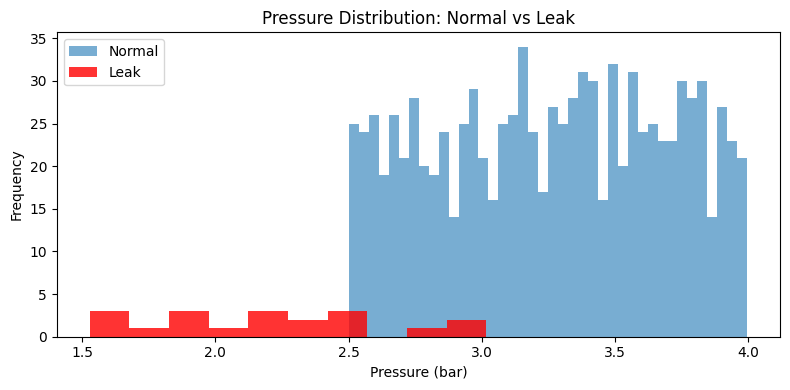

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
df_focus[df_focus['Leak Status']==0]['Pressure (bar)'].plot.hist(
    bins=40, alpha=0.6, label='Normal', ax=ax)
df_focus[df_focus['Leak Status']==1]['Pressure (bar)'].plot.hist(
    bins=10, alpha=0.8, label='Leak', ax=ax, color='red')
ax.set_xlabel('Pressure (bar)')
ax.set_title('Pressure Distribution: Normal vs Leak')
ax.legend()
plt.tight_layout()
plt.show()


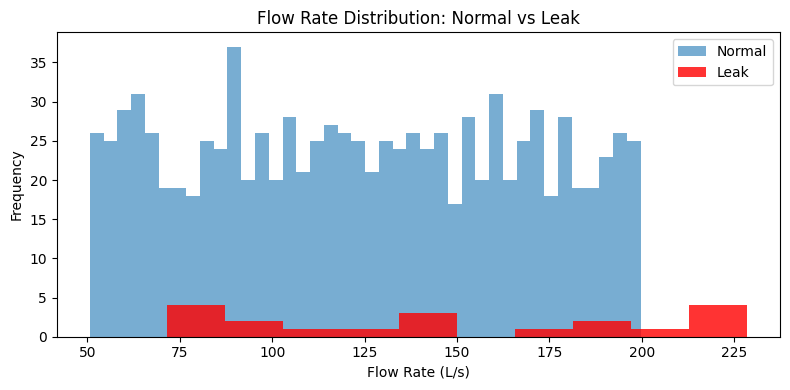

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))
df_focus[df_focus['Leak Status']==0]['Flow Rate (L/s)'].plot.hist(
    bins=40, alpha=0.6, label='Normal', ax=ax)
df_focus[df_focus['Leak Status']==1]['Flow Rate (L/s)'].plot.hist(
    bins=10, alpha=0.8, label='Leak', ax=ax, color='red')
ax.set_xlabel('Flow Rate (L/s)')
ax.set_title('Flow Rate Distribution: Normal vs Leak')
ax.legend()
plt.tight_layout()
plt.show()


Using sensor: S010


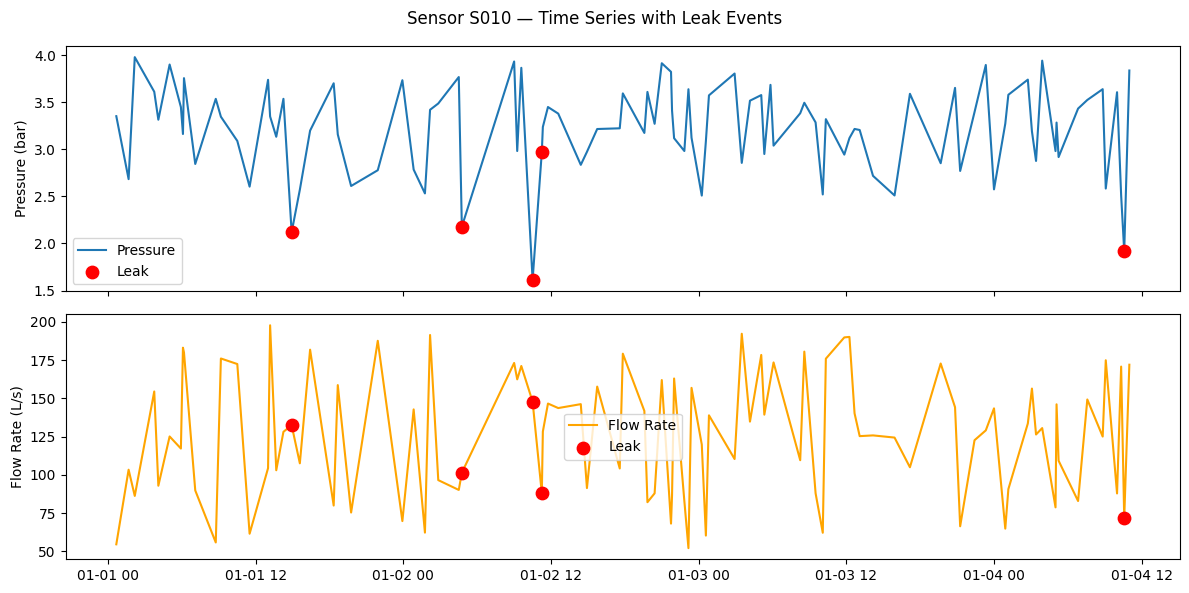

In [11]:
# Pick a sensor that has at least one leak
sensor_leaks = df[df['Leak Status']==1]['Sensor_ID'].value_counts()
chosen = sensor_leaks.index[0]
print(f"Using sensor: {chosen}")

sub = df[df['Sensor_ID'] == chosen].sort_values('Timestamp')
leaks = sub[sub['Leak Status'] == 1]

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

axes[0].plot(sub['Timestamp'], sub['Pressure (bar)'], label='Pressure')
axes[0].scatter(leaks['Timestamp'], leaks['Pressure (bar)'],
                color='red', zorder=5, label='Leak', s=80)
axes[0].set_ylabel('Pressure (bar)')
axes[0].legend()

axes[1].plot(sub['Timestamp'], sub['Flow Rate (L/s)'], label='Flow Rate', color='orange')
axes[1].scatter(leaks['Timestamp'], leaks['Flow Rate (L/s)'],
                color='red', zorder=5, label='Leak', s=80)
axes[1].set_ylabel('Flow Rate (L/s)')
axes[1].legend()

plt.suptitle(f'Sensor {chosen} — Time Series with Leak Events')
plt.tight_layout()
plt.show()


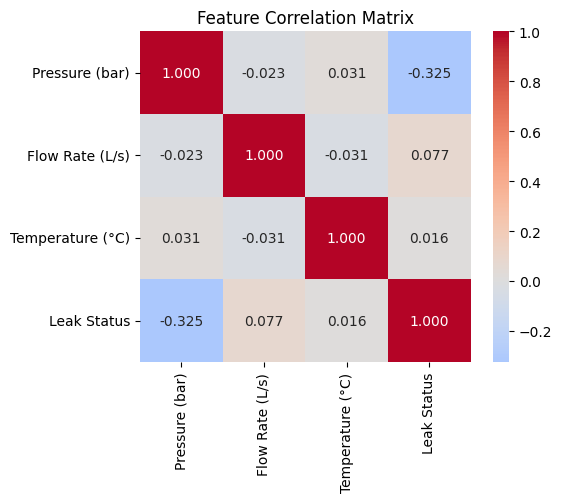

In [12]:
corr = df_focus[['Pressure (bar)', 'Flow Rate (L/s)',
                  'Temperature (°C)', 'Leak Status']].corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm',
            center=0, ax=ax, square=True)
ax.set_title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()


In [ ]:
# Save the burst-removed version for all next notebooks
df_clean = df[df['Burst Status'] == 0].copy().drop(columns=['Burst Status'])
df_clean = df_clean.sort_values(['Sensor_ID', 'Timestamp']).reset_index(drop=True)
df_clean.to_csv(DATA_DIR+"/data_clean.csv", index=False)

print(f"Saved data/data_clean.csv")
print(f"Shape  : {df_clean.shape}")
print(f"Leaks  : {df_clean['Leak Status'].sum()}")


OSError: Cannot save file into a non-existent directory: 'data'